# 05. 통합 Knowledge Agent

- 핵심 선수 실습: 02-2_langgraph_routing_multitool.ipynb, 02-3_langgraph_tool_agent.ipynb, 03-3_agentic_rag_basic.ipynb
- 확장 선수 실습: 04-1_context_state_memory.ipynb, 04-2_checkpoint_human_in_the_loop.ipynb
- 핵심 기술: Adaptive Workflow, `MessagesState`, `ToolNode`, Chroma, Checkpointer, HITL
- 최종 산출물: 8가지 대표 시나리오를 처리하는 10-Node Hybrid Knowledge Agent


## 1. 학습목표

이 실습을 완료하면 다음을 수행할 수 있다.

1. Routing, Tool Agent, Agentic RAG, Checkpoint/HITL을 하나의 Graph로 통합할 수 있다.
2. 상위 수준의 조건 분기 Workflow와 하위 수준의 LLM Tool Agent Loop를 구분해 설계할 수 있다.
3. LLM이 검색·계산 Tool을 선택하고 `ToolNode`가 실행한 결과를 다시 State에 연결하도록 구현할 수 있다.
4. 정보 부족 시 `interrupt()`로 실행을 멈추고 `Command(resume=...)`로 같은 Thread를 재개할 수 있다.
5. 검색 실패, Tool 실행 실패, 사용자 확인을 서로 다른 State와 경로로 처리할 수 있다.


## 2. 문제 상황

지금까지 만든 Agent는 각각 한 가지 능력에 집중했다. Notebook 02-2는 입력 유형에 따른
조건 분기 Workflow를, 02-3은 `MessagesState`와 `ToolNode`를 사용한 Agent Loop를,
03-3은 Chroma 검색과 근거 검증을, 04-2는 Checkpoint와 HITL을 다뤘다.

이번 실습은 이 기능을 하나로 연결한다. 상위 Graph가 입력 유형·정보 충분성·근거
적합성을 관리하고, 실제 검색과 계산은 LLM이 Tool을 선택하는 하위 Agent Loop가
담당한다. 따라서 결과물은 순수 Tool Agent도, 단순 Routing Workflow도 아닌
**Adaptive Workflow + Tool Agent의 Hybrid 구조**다.


## 3. 핵심 개념

### 3.1 Workflow와 Agent Loop의 역할 분리

| 계층 | 담당 역할 | 주요 API |
|---|---|---|
| Adaptive Workflow | 입력 분류, 정보 부족 확인, 검색 필요성, 근거 검증, 재시도·종료 | `StateGraph`, Conditional Edge |
| Tool Agent Loop | LLM의 Tool 선택, Tool 실행, 계산 결과를 다시 LLM에 전달 | `MessagesState`, `ToolNode`, `tools_condition` |
| Persistence/HITL | 중단 시 State 저장, 같은 Thread에서 사용자 응답으로 재개 | `InMemorySaver`, `interrupt`, `Command` |

### 3.2 10개 단일 책임 Node

| Node | 역할 |
|---|---|
| `input_classifier` | 입력 유형 분류 |
| `fact_extractor` | 계산식 또는 문서 키워드 추출 |
| `missing_information_checker` | 처리에 필요한 정보 확인 |
| `request_clarification` | 정보 부족 시 HITL 중단·재개 |
| `search_requirement_checker` | 검색·계산·직접 응답 경로 결정 |
| `generate_search_query` | 최초 검색어 또는 재검색어 생성 |
| `tool_agent` | LLM이 검색·계산 Tool 선택, 계산 Tool 결과 해석 |
| `tools` | `ToolNode`가 Tool 실행 및 State 갱신 |
| `evidence_validator` | 검색 근거 적합성 판단과 재시도 횟수 관리 |
| `response_generator` | 최종 답변·인용·오류 형식 통합 |

### 3.3 핵심 실행 흐름

```text
입력 → 분류 → 사실 추출 → 정보 확인
                         ├─ 부족 → interrupt() ⇢ Command(resume=...) → 검색 판단
                         └─ 충분 → 검색 판단
                                      ├─ 일반 질문 → 최종 응답
                                      ├─ 계산 → LLM → ToolNode → LLM → 최종 응답
                                      └─ 문서 → 검색어 → LLM → ToolNode
                                                            ↓
                                                       근거 검증
                                                       ├─ 재검색 ─┐
                                                       └─ 응답     │
                                                                  └─ 검색어 생성으로 복귀
```

### 3.4 중요한 설계 판단

- 계산식 추출과 검색 필요성 같은 결정적 규칙은 Python Node가 담당한다.
- 어떤 Tool을 호출할지는 Tool이 바인딩된 LLM이 결정한다.
- Chroma가 Embedding, 유사도 계산, 정렬, Top-k 선택을 담당한다.
- 검색 실패는 재검색할 수 있지만 0으로 나누기 같은 Tool 실패는 반복해도 달라지지 않으므로 즉시 오류 응답으로 보낸다.
- `request_clarification`은 응답을 만들고 끝나는 Node가 아니라 실행을 중단하고 재개하는 실제 HITL Node다.


## 4. 실행 구조

이 Graph는 한 번에 조립하지 않고 2단계로 나눠 만든다. 1단계는 Tool Agent 루프
없이 분류·정보확인·HITL만 연결해 먼저 확인하고, 2단계에서 검색·계산을 담당하는
Tool Agent 루프를 얹어 최종 10-Node Graph를 완성한다.

```text
[1단계] build_basic_integration_graph(checkpointer)
   input_classifier → fact_extractor → missing_information_checker
   request_clarification → search_requirement_checker → response_generator
   (검색·계산은 아직 없음, HITL만 실제로 동작)
```

```mermaid
flowchart TD
    START([START]) --> input_classifier
    input_classifier --> fact_extractor
    fact_extractor --> missing_information_checker
    missing_information_checker -.insufficient.-> request_clarification
    missing_information_checker -.sufficient.-> search_requirement_checker
    request_clarification --> search_requirement_checker
    search_requirement_checker -.respond.-> response_generator
    response_generator --> END([END])

```

```text
[2단계] build_knowledge_agent_graph(checkpointer)
   ├─ StateGraph(KnowledgeAgentState)
   ├─ 10개 Node 등록
   │   input_classifier → fact_extractor → missing_information_checker
   │   request_clarification → search_requirement_checker → generate_search_query
   │   tool_agent ⇄ tools → evidence_validator → response_generator
   ├─ tools_condition으로 LLM Tool 호출 여부 분기
   ├─ evidence_validator에서 재검색 종료 조건 관리
   └─ compile(checkpointer=InMemorySaver())

첫 실행: graph.invoke(initial_state, {"configurable": {"thread_id": ...}})
HITL 재개: graph.invoke(Command(resume="추가 정보"), 같은 config)
```

```mermaid
flowchart TD
    START([START]) --> input_classifier
    input_classifier --> fact_extractor
    fact_extractor --> missing_information_checker
    missing_information_checker -.insufficient.-> request_clarification
    missing_information_checker -.sufficient.-> search_requirement_checker
    request_clarification --> search_requirement_checker
    search_requirement_checker -.required.-> generate_search_query
    search_requirement_checker -.tool.-> tool_agent
    search_requirement_checker -.respond.-> response_generator
    generate_search_query --> tool_agent
    tool_agent -.-> tools
    tool_agent -.respond.-> response_generator
    tools -.validate.-> evidence_validator
    tools -.agent.-> tool_agent
    evidence_validator -.retry.-> generate_search_query
    evidence_validator -.generate.-> response_generator
    response_generator --> END([END])
```

## 5. 환경 설정

반복되는 경로 탐색과 모델 생성 코드는 `src/agentic_ai` 공통 모듈에서 관리한다.
아래 셀에서는 이 Notebook에 필요한 표준 라이브러리와 공통 기능만 불러온다.

> 처음 실행하거나 환경 오류가 발생하면 프로젝트 루트의
> `00_environment_check.ipynb`를 먼저 실행한다.


In [1]:
import json
from typing import TypedDict

from langchain.tools import ToolRuntime, tool
from langchain_core.documents import Document
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt

from agentic_ai.config import get_settings
from agentic_ai.logging_utils import save_log
from agentic_ai.models import get_chat_model, get_embedding_model
from agentic_ai.notebook_utils import print_environment_summary, show_graph
from agentic_ai.paths import CHROMA_DIR, OUTPUT_DIR
from agentic_ai.retrieval_utils import add_documents_if_empty, get_chroma_store
from agentic_ai.tools import calculate

settings = get_settings()
print_environment_summary(
    settings,
    needs_chat_model=True,
    needs_embedding_model=True,
)

chat_model = get_chat_model()
embedding_model = get_embedding_model()

LLM_CALL_COUNT = 0


def call_llm(prompt: str) -> str:
    # LLM 호출 횟수를 세면서 chat_model을 호출한다.
    global LLM_CALL_COUNT
    LLM_CALL_COUNT += 1
    return chat_model.invoke(prompt).content


[환경 설정 확인]
- 프로젝트: E:\agentic_ai_lab
- 데이터: E:\agentic_ai_lab\data
- 출력: E:\agentic_ai_lab\outputs
- OPENAI_API_KEY: 설정됨
- Chat Model: gpt-4.1-mini
- Embedding Model: text-embedding-3-small


## 6. 최소 실행 예제

전체 Graph를 만들기 전에, "근거가 부족하면 다시 검색하고, 재시도 횟수를 넘기면
포기한다"는 재시도 루프의 핵심 동작만 아주 단순한 형태로 먼저 확인한다.

In [2]:
class RetryState(TypedDict):
    attempts: int
    max_attempts: int
    success: bool


def try_once(state: RetryState) -> dict:
    attempts = state["attempts"] + 1
    return {"attempts": attempts, "success": attempts >= 3}


def route_retry(state: RetryState) -> str:
    if state["success"]:
        return "done"
    if state["attempts"] < state["max_attempts"]:
        return "retry"
    return "give_up"


def done_node(state: RetryState) -> dict:
    return {}


def give_up_node(state: RetryState) -> dict:
    return {}


retry_builder = StateGraph(RetryState)
retry_builder.add_node("try_once", try_once)
retry_builder.add_node("done", done_node)
retry_builder.add_node("give_up", give_up_node)
retry_builder.add_edge(START, "try_once")
retry_builder.add_conditional_edges(
    "try_once", route_retry, {"retry": "try_once", "done": "done", "give_up": "give_up"}
)
retry_builder.add_edge("done", END)
retry_builder.add_edge("give_up", END)
retry_graph = retry_builder.compile()



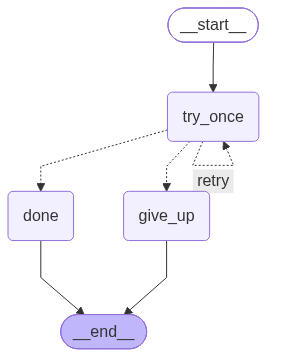

In [3]:
# 시각화는 네트워크 환경에 따라 실패할 수 있으므로 선택적으로 실행한다.
show_graph(retry_graph)

In [4]:
print(retry_graph.invoke({"attempts": 0, "max_attempts": 5, "success": False}))
print(retry_graph.invoke({"attempts": 0, "max_attempts": 2, "success": False}))

{'attempts': 3, 'max_attempts': 5, 'success': True}
{'attempts': 2, 'max_attempts': 2, 'success': False}


## 7. 단계별 구현

### 7.1 `MessagesState` 확장

Tool Agent의 대화와 Tool 호출 이력은 `messages` reducer에 누적한다. 여기에 통합
Workflow가 필요한 분류·검색·오류·인용 필드를 추가한다.


In [5]:
# MessagesState를 상속해 messages에는 reducer가 적용되고 나머지는 일반 State 필드로 갱신된다.
class KnowledgeAgentState(MessagesState):
    user_input: str
    input_type: str
    extracted_facts: dict
    missing_information: list[str]
    clarification: str

    search_required: bool
    search_queries: list[str]
    retrieved_documents: list[dict]
    evidence_valid: bool

    selected_tools: list[str]
    tool_results: list[dict]

    retry_count: int
    max_retries: int
    completed: bool
    error: str | None

    citations: list[dict]
    final_answer: str


MAX_RETRIES = 2


def new_state(user_input: str) -> KnowledgeAgentState:
    """테스트와 실행에서 반복 사용할 초기 State를 만든다."""
    # 호출마다 새 리스트와 dict를 만들어 서로 다른 실행의 상태가 섞이지 않게 한다.
    return {
        "messages": [HumanMessage(content=user_input)],
        "user_input": user_input,
        "input_type": "",
        "extracted_facts": {},
        "missing_information": [],
        "clarification": "",
        "search_required": False,
        "search_queries": [],
        "retrieved_documents": [],
        "evidence_valid": False,
        "selected_tools": [],
        "tool_results": [],
        "retry_count": 0,
        "max_retries": MAX_RETRIES,
        "completed": False,
        "error": None,
        "citations": [],
        "final_answer": "",
    }

### 7.2 Chroma Vector Store 구성

`outputs/vectorstore/chroma` 경로에 `sample_documents` Collection을 연다.
이미 같은 이름의 Collection이 있으면(예: 03-2 실습을 먼저 실행한 경우) 그대로
재사용하고, 비어 있을 때만 실습용 문서를 새로 추가한다. Embedding, 유사도 계산,
정렬, Top-k 선택은 Chroma에 맡기고 이 실습은 Agent 흐름에 집중한다.

In [6]:
SAMPLE_DOCUMENTS = [
    {"doc_id": "d1", "document_id": "report-01", "section": "개요",
     "text": "본 보고서는 2025년 한 해 동안 시행된 리모트워크 제도의 운영 현황을 정리하고, 2026년도 제도 개선 방향을 제시하기 위해 작성되었다."},
    {"doc_id": "d2", "document_id": "report-01", "section": "운영 현황",
     "text": "2025년 기준 전체 임직원의 62%가 주 2회 이상 리모트워크를 사용하였다. 부서별로는 개발팀의 사용률이 81%로 가장 높았고, 영업팀은 24%로 가장 낮았다."},
    {"doc_id": "d3", "document_id": "report-01", "section": "만족도 조사 결과",
     "text": "전체 응답자의 74%가 리모트워크 제도에 만족한다고 응답하였다. 불만족 사유로는 협업 지연, 화상회의 피로도, 장비 지원 부족 순으로 나타났다."},
    {"doc_id": "d4", "document_id": "report-01", "section": "문제점",
     "text": "일부 부서에서 리모트워크와 사무실 근무 인원 간 정보 격차가 발생하였다. 특히 신입 직원의 온보딩 과정에서 어려움을 겪는 사례가 보고되었다."},
    {"doc_id": "d5", "document_id": "report-01", "section": "개선 방향",
     "text": "2026년에는 팀별 필수 출근일을 지정하고, 화상회의 시간을 기본 30분으로 단축하는 가이드라인을 도입할 예정이다."},
    {"doc_id": "d6", "document_id": "report-01", "section": "결론",
     "text": "리모트워크 제도는 임직원 만족도와 생산성 측면에서 긍정적인 효과를 보였으나, 협업과 온보딩 절차에 대한 보완이 필요하다."},
]

VECTOR_DOCUMENTS = [
    Document(
        page_content=record["text"],
        metadata={key: value for key, value in record.items() if key != "text"},
    )
    for record in SAMPLE_DOCUMENTS
]

COLLECTION_NAME = "sample_documents"
vector_store = get_chroma_store(
    COLLECTION_NAME,
    embedding_model=embedding_model,
)
# 영속 Collection이 비어 있을 때만 적재해 Notebook 재실행 시 중복 문서를 막는다.
documents_added, document_count = add_documents_if_empty(
    vector_store,
    VECTOR_DOCUMENTS,
    ids=[record["doc_id"] for record in SAMPLE_DOCUMENTS],
)

action = "초기화" if documents_added else "sample_documents Collection 재사용"
print(f"{action}: {document_count}개 문서")


def retrieve(query: str, k: int = 2) -> list[dict]:
    """Chroma에서 질문과 관련된 상위 k개 문서를 가져온다."""
    if k < 1:
        raise ValueError("k는 1 이상이어야 합니다.")
    matches = vector_store.similarity_search_with_relevance_scores(query, k=k)
    return [
        {**document.metadata, "text": document.page_content, "similarity": score}
        for document, score in matches
    ]


@tool
def calculate_knowledge_tool(expression: str, runtime: ToolRuntime) -> Command:
    """사칙연산 수식을 안전하게 계산한다."""
    # runtime은 모델이 만드는 인자가 아니라 LangGraph가 현재 State와 call 정보를 주입한다.
    try:
        value = calculate(expression)
        result = {"tool": "calculate_knowledge_tool", "success": True, "value": value}
        error = None
    except ValueError as exc:
        result = {"tool": "calculate_knowledge_tool", "success": False, "error": str(exc)}
        error = str(exc)

    # Command로 Tool 결과, 오류, 메시지를 하나의 원자적인 State update로 반환한다.
    return Command(update={
        "selected_tools": runtime.state["selected_tools"] + ["calculate_knowledge_tool"],
        "tool_results": runtime.state["tool_results"] + [result],
        "error": error,
        "messages": [ToolMessage(
            content=json.dumps(result, ensure_ascii=False),
            # Tool Call id를 연결해야 모델이 어느 호출의 결과인지 식별할 수 있다.
            tool_call_id=runtime.tool_call_id,
        )],
    })


@tool
def search_knowledge_tool(query: str, runtime: ToolRuntime) -> Command:
    """Chroma에서 Knowledge Agent의 근거 문서를 검색한다."""
    documents = retrieve(query, k=2)
    result = {
        "tool": "search_knowledge_tool",
        "success": True,
        "query": query,
        "document_ids": [doc["doc_id"] for doc in documents],
    }
    # 재검색에서는 최신 후보군을 평가해야 하므로 retrieved_documents를 새 결과로 교체한다.
    return Command(update={
        "retrieved_documents": documents,
        "selected_tools": runtime.state["selected_tools"] + ["search_knowledge_tool"],
        "tool_results": runtime.state["tool_results"] + [result],
        "error": None,
        "messages": [ToolMessage(
            content=json.dumps(result, ensure_ascii=False),
            tool_call_id=runtime.tool_call_id,
        )],
    })


KNOWLEDGE_TOOLS = [calculate_knowledge_tool, search_knowledge_tool]
# bind_tools는 선택 가능한 Schema만 모델에 제공하며 실제 실행은 ToolNode가 담당한다.
tool_model = chat_model.bind_tools(KNOWLEDGE_TOOLS)


sample_documents Collection 재사용: 9개 문서


### 7.3 입력 분류 Node

규칙 기반으로 입력을 4가지 유형으로 분류한다(Notebook 02-2의 `classify_input`을
확장). `"문서"`가 포함되면 세부 정보(따옴표로 감싼 키워드)가 있는지와 무관하게
일단 `"document"`로 분류하고, 세부 정보 확인은 이후 `missing_information_checker`가
담당한다.

In [7]:
def classify_input(state: KnowledgeAgentState) -> dict:
    """규칙 기반으로 입력 유형을 분류한다."""
    text = state["user_input"]
    # 조건이 겹칠 수 있으므로 구체적인 문서·계산 규칙을 일반 질문보다 먼저 검사한다.
    if "문서" in text:
        input_type = "document"
    elif any(ch.isdigit() for ch in text) and any(
        op in text for op in ["+", "-", "*", "/", "더하기", "빼기", "곱하기", "나누기"]
    ):
        input_type = "calculation"
    elif text.strip().endswith(("?", "까요", "나요")):
        input_type = "question"
    else:
        input_type = "unsupported"
    return {"input_type": input_type}


print(classify_input(new_state("128 나누기 4는 얼마야?")))
print(classify_input(new_state("문서에서 '온보딩' 관련 내용을 분석해줘")))

{'input_type': 'calculation'}
{'input_type': 'document'}


### 7.4 사실 추출 Node

`fact_extractor`는 계산 요청에서 수식, 문서 요청에서 따옴표 안 키워드만 추출한다.
여기서는 Tool을 직접 호출하지 않는다. 실제 Tool 선택은 뒤의 `tool_agent`, 실행은
`ToolNode`가 담당하므로 Notebook 01-3~01-4의 Agent Loop가 LangGraph 구조로 이어진다.


In [8]:
_OP_WORDS = {"더하기": "+", "빼기": "-", "곱하기": "*", "나누기": "/"}


def extract_expression(text: str) -> str:
    """자연어 계산 요청에서 사칙연산 수식만 추출한다."""
    cleaned = text
    for word, symbol in _OP_WORDS.items():
        cleaned = cleaned.replace(word, f" {symbol} ")
    allowed = set("0123456789+-*/. ")
    return "".join(ch for ch in cleaned if ch in allowed).strip()


def extract_keyword_query(text: str) -> str:
    """'키워드' 형식의 문서 요청에서 따옴표 안 내용을 추출한다."""
    parts = text.split("'")
    return parts[1].strip() if len(parts) >= 3 else ""


def fact_extractor(state: KnowledgeAgentState) -> dict:
    # 새 요청을 처리할 때 이전 Tool 선택·결과·오류가 남지 않도록 함께 초기화한다.
    if state["input_type"] == "calculation":
        return {
            "extracted_facts": {"expression": extract_expression(state["user_input"])},
            "selected_tools": [],
            "tool_results": [],
            "error": None,
        }
    if state["input_type"] == "document":
        return {
            "extracted_facts": {"query": extract_keyword_query(state["user_input"])},
            "selected_tools": [],
            "tool_results": [],
            "error": None,
        }
    return {"extracted_facts": {}, "selected_tools": [], "tool_results": [], "error": None}


print(fact_extractor({**new_state("128 나누기 4는 얼마야?"), "input_type": "calculation"}))
print(fact_extractor({**new_state("문서에서 '온보딩' 찾아줘"), "input_type": "document"}))


{'extracted_facts': {'expression': '128  /  4'}, 'selected_tools': [], 'tool_results': [], 'error': None}
{'extracted_facts': {'query': '온보딩'}, 'selected_tools': [], 'tool_results': [], 'error': None}


### 7.5 정보 부족 확인 Node

**TODO**: `missing_information_checker()`를 작성한다.

- `input_type`이 `"document"`이고 `extracted_facts.get("query")`가 빈
  문자열이면, `missing_information`에 `"target_keyword"`를 담아 반환한다.
- 그 외의 경우(계산, 질문, 지원하지 않는 입력, 또는 키워드가 있는 문서 요청)는
  `missing_information`을 빈 리스트로 반환한다.
- 반환값은 항상 `{"missing_information": [...]}` 형태의 딕셔너리여야 한다.

예상 출력: `missing_information_checker({..., "input_type": "document",
"extracted_facts": {"query": ""}})` → `{"missing_information": ["target_keyword"]}`

In [9]:
def missing_information_checker(state: KnowledgeAgentState) -> dict:
    """처리에 필요한 정보가 충분한지 확인한다."""
    if state["input_type"] == "document" and not state["extracted_facts"].get("query"):
        return {"missing_information": ["target_keyword"]}
    return {"missing_information": []}


check_missing = {**new_state("이 문서를 검토해줘"), "input_type": "document", "extracted_facts": {"query": ""}}
assert missing_information_checker(check_missing)["missing_information"] == ["target_keyword"]

check_ok = {**new_state("문서에서 '온보딩' 찾아줘"), "input_type": "document", "extracted_facts": {"query": "온보딩"}}
assert missing_information_checker(check_ok)["missing_information"] == []
print("missing_information_checker 동작 확인 완료")

missing_information_checker 동작 확인 완료


### 7.6 실제 HITL과 처리 경로 판단

문서 키워드가 없으면 `request_clarification`에서 `interrupt()`가 Graph를 멈춘다.
Checkpointer가 현재 State를 Thread에 저장하므로, 같은 `thread_id`와
`Command(resume=...)`를 사용하면 사용자의 추가 정보를 받아 Node 실행을 이어간다.


In [10]:
def route_after_missing_check(state: KnowledgeAgentState) -> str:
    # 반환 키는 conditional edge의 path map과 정확히 일치해야 한다.
    return "insufficient" if state["missing_information"] else "sufficient"


def request_clarification(state: KnowledgeAgentState) -> dict:
    # interrupt payload에는 질문뿐 아니라 재개 후 필요한 원래 요청과 누락 필드도 담는다.
    clarification = interrupt({
        "question": "어떤 내용을 검토할까요? 검색할 키워드를 입력해 주세요.",
        "missing_information": state["missing_information"],
        "original_request": state["user_input"],
    })
    query = str(clarification).strip()
    return {
        "clarification": query,
        # 사용자 보충 정보를 원본 요청과 추출 사실 양쪽에 반영해 후속 Node가 바로 사용하게 한다.
        "user_input": f"{state['user_input']}\n사용자 추가 정보: {query}",
        "extracted_facts": {**state["extracted_facts"], "query": query},
        "missing_information": [],
        "completed": False,
        "final_answer": "",
    }


def search_requirement_checker(state: KnowledgeAgentState) -> dict:
    required = state["input_type"] == "document" and state["error"] is None
    return {"search_required": required}


def route_after_search_requirement(state: KnowledgeAgentState) -> str:
    # Tool 실행보다 기존 오류 처리를 우선해 실패 State가 잘못된 경로로 진행되지 않게 한다.
    if state["error"]:
        return "respond"
    if state["search_required"]:
        return "required"
    if state["input_type"] == "calculation":
        return "tool"
    return "respond"


### 7.7 검색어 생성, Tool Agent, 근거 평가

문서 경로는 검색어를 만든 뒤 `tool_agent`로 들어간다. `tool_agent`의 LLM이
`search_knowledge_tool` 또는 `calculate_knowledge_tool`을 선택하고, `ToolNode`가
실행한다. 계산 경로는 Tool 결과를 다시 LLM에 전달하는 `LLM → Tool → LLM`
순환을 완성한다. 문서 경로는 검색 결과를 State에 저장한 뒤 근거 검증으로 이동한다.


In [11]:
def generate_search_query(state: KnowledgeAgentState) -> dict:
    """첫 검색어를 만들고, 근거가 부족하면 이전 검색어를 구체화한다."""
    base_query = state["extracted_facts"].get("query") or state["user_input"]
    if state["retry_count"] == 0:
        query = base_query
    else:
        previous = state["search_queries"][-1]
        query = call_llm(
            f"원본 요청: {state['user_input']}\n이전 검색어: {previous}\n"
            "이전과 다른 관점의 구체적인 한국어 검색어만 작성하세요."
        ).strip()
    # 검색어 이력을 덮어쓰지 않고 누적해 다음 재검색 프롬프트에서 참조한다.
    return {"search_queries": state["search_queries"] + [query]}


TOOL_AGENT_PROMPT = """당신은 Knowledge Agent의 Tool 선택 담당자입니다.
- 계산 요청이면 calculate_knowledge_tool만 호출하세요.
- 문서 검색 요청이면 search_knowledge_tool만 호출하세요.
- 제공된 수식 또는 검색어를 임의로 바꾸지 마세요.
- 계산 Tool 결과가 이미 주어졌다면 Tool을 반복 호출하지 말고 한국어 최종 답변을 작성하세요.
- 문서 검색에서는 새 검색어가 과제로 주어질 때마다 search_knowledge_tool을 호출하세요.
"""


def tool_agent_node(state: KnowledgeAgentState) -> dict:
    """LLM이 필요한 Tool을 선택하거나 계산 Tool 결과를 해석한다."""
    global LLM_CALL_COUNT
    # 같은 Agent Node를 공유하되 입력 유형에 따라 모델에게 줄 작업을 명확히 분리한다.
    if state["input_type"] == "calculation":
        task = f"다음 수식을 계산하세요: {state['extracted_facts'].get('expression', '')}"
    else:
        task = f"Chroma에서 다음 검색어로 근거 문서를 검색하세요: {state['search_queries'][-1]}"

    has_calculation_result = (
        state["input_type"] == "calculation"
        and isinstance(state["messages"][-1], ToolMessage)
    )
    # 계산 결과를 받은 뒤에는 Tool이 없는 모델로 바꿔 동일 Tool의 반복 호출을 막는다.
    model = chat_model if has_calculation_result else tool_model
    response = model.invoke([
        SystemMessage(content=TOOL_AGENT_PROMPT),
        *state["messages"],
        HumanMessage(content=task),
    ])
    LLM_CALL_COUNT += 1
    return {"messages": [response]}


def route_after_tool_agent(state: KnowledgeAgentState) -> str:
    # tools_condition의 판단을 이 Graph의 path map 키로 단순화한다.
    return "tools" if tools_condition(state) == "tools" else "respond"


def route_after_tools(state: KnowledgeAgentState) -> str:
    # 문서 검색 결과는 근거 검증으로, 계산 결과는 Agent의 자연어 해석으로 되돌린다.
    return "validate" if state["input_type"] == "document" else "agent"


def evidence_validator(state: KnowledgeAgentState) -> dict:
    docs_text = "\n".join(f"- {d['text']}" for d in state["retrieved_documents"])
    prompt = (
        f"질문: {state['user_input']}\n"
        f"재검색 시도 횟수: {state['retry_count']}\n"
        f"검색된 문서:\n{docs_text}\n"
        "위 문서가 질문에 충분한 근거가 되는지 판단하세요. "
        "EVIDENCE: sufficient 또는 EVIDENCE: insufficient 형식으로만 답하세요."
    )
    response = call_llm(prompt)
    # 'insufficient' 안에도 'sufficient'가 포함되므로 부정 표현을 함께 배제한다.
    valid = "EVIDENCE: sufficient" in response and "insufficient" not in response
    update: dict = {"evidence_valid": valid}
    if not valid:
        # 근거가 부족한 평가에서만 횟수를 증가시켜 재검색 한도를 계산한다.
        update["retry_count"] = state["retry_count"] + 1
    return update


### 7.8 재검색 조건과 최대 재시도 횟수

**TODO**: `route_after_evidence()`를 작성한다. `evidence_validator` 다음에 실행할
Node 이름을 문자열로 반환하는 LangGraph 조건 분기 함수다.

- `state["evidence_valid"]`가 `True`이면 `"generate"`를 반환한다.
- `evidence_valid`가 `False`이고 `state["retry_count"] < state["max_retries"]`이면
  `"retry"`를 반환한다.
- 그 외(근거가 여전히 부족하고 재시도 횟수도 소진된 경우, 즉 검색 실패)에는
  `"generate"`를 반환한다. `response_generator`가 `evidence_valid` 값을 보고
  근거 부족 Fallback 메시지를 만들 것이다.

In [12]:
def route_after_evidence(state: KnowledgeAgentState) -> str:
    """근거 적합성과 재시도 횟수에 따라 다음 Node를 결정한다."""
    # 한도 전에는 재검색하고, 한도 소진 후에는 response_generator가 안전한 실패 답을 만든다.
    if state["evidence_valid"]:
        return "generate"
    if state["retry_count"] < state["max_retries"]:
        return "retry"
    return "generate"


assert route_after_evidence({"evidence_valid": True, "retry_count": 0, "max_retries": MAX_RETRIES}) == "generate"
assert route_after_evidence({"evidence_valid": False, "retry_count": 0, "max_retries": MAX_RETRIES}) == "retry"
assert route_after_evidence({"evidence_valid": False, "retry_count": MAX_RETRIES, "max_retries": MAX_RETRIES}) == "generate"
print("route_after_evidence 동작 확인 완료")

route_after_evidence 동작 확인 완료


### 7.9 최종 응답 생성 Node

`response_generator`는 오류 → 미지원 입력 → 검색 결과 → 계산 결과 → 일반 질문
순서로 확인한다. 계산 답변은 Tool 실행 후 두 번째 LLM 메시지를 사용하고,
검색 답변에는 Chroma에서 반환된 문서 ID와 Section을 인용으로 남긴다.


In [13]:
SEARCH_FAILURE_MESSAGE = "확인된 근거가 부족하여 확정적으로 답변할 수 없습니다. 관련 문서를 다시 확인해 주세요."
UNSUPPORTED_MESSAGE = "지원하지 않는 요청입니다. 질문, 문서 검색, 계산 요청만 처리할 수 있습니다."


def response_generator(state: KnowledgeAgentState) -> dict:
    # 성공 결과를 읽기 전에 error를 확인해 실패 Tool의 누락 필드 접근을 막는다.
    if state["error"]:
        return {"final_answer": f"[오류] {state['error']}", "citations": [], "completed": True}

    if state["input_type"] == "unsupported":
        return {"final_answer": UNSUPPORTED_MESSAGE, "citations": [], "completed": True}

    if state["search_required"]:
        if state["evidence_valid"]:
            docs_text = "\n".join(f"[{d['doc_id']}] {d['text']}" for d in state["retrieved_documents"])
            answer = call_llm(
                f"질문: {state['user_input']}\n"
                "아래 근거에 있는 내용만 사용하고, 없는 내용은 추정하지 마세요.\n"
                f"{docs_text}"
            )
            # 인용은 모델 출력이 아니라 실제 검색 문서 metadata에서 구성한다.
            citations = [
                {"doc_id": d["doc_id"], "section": d["section"]}
                for d in state["retrieved_documents"]
            ]
            return {"final_answer": answer, "citations": citations, "completed": True}
        return {"final_answer": SEARCH_FAILURE_MESSAGE, "citations": [], "completed": True}

    if state["input_type"] == "calculation":
        agent_messages = [
            message.content
            for message in state["messages"]
            if isinstance(message, AIMessage) and message.content and not message.tool_calls
        ]
        if agent_messages:
            answer = agent_messages[-1]
        else:
            # 모델의 최종 메시지가 없을 때만 가장 최근의 성공 Tool 결과를 fallback으로 사용한다.
            successful = next((r for r in reversed(state["tool_results"]) if r.get("success")), None)
            answer = f"계산 결과: {successful['value']}" if successful else "계산 결과를 만들지 못했습니다."
        return {"final_answer": answer, "citations": [], "completed": True}

    answer = call_llm(f"질문: {state['user_input']}\n문서 검색 없이 직접 답변하세요.")
    return {"final_answer": answer, "citations": [], "completed": True}


### 7.10 1단계 체크포인트: Tool Agent 없이 분류·HITL까지 먼저 연결

10개 Node를 한 번에 연결하기 전에, Tool Agent 루프(`generate_search_query`,
`tool_agent`, `tools`, `evidence_validator`)를 뺀 6-Node Graph를 먼저 조립해서
확인한다. 이 단계에서는 검색과 계산을 실제로 수행하지 않으므로, 문서·계산
요청은 아직 답을 만들지 못하고 안전하게 "근거 부족" 또는 "계산 결과를 만들지
못했습니다"로 응답한다. 반면 일반 질문 직접 응답과 `interrupt()`/
`Command(resume=...)`를 이용한 HITL 중단·재개는 이 단계에서 이미 완전히
동작한다. 이 체크포인트를 먼저 통과한 뒤에 7.11에서 Tool Agent 루프를 추가로
연결한다.

In [14]:
def route_after_search_requirement_stage1(state: KnowledgeAgentState) -> str:
    """1단계에는 검색·계산 실행 경로가 아직 없으므로 항상 바로 응답 생성으로 간다."""
    return "respond"


def build_basic_integration_graph(checkpointer=None):
    """Tool Agent 루프 없이 분류·정보확인·HITL까지만 연결한 1단계 체크포인트 Graph."""
    builder = StateGraph(KnowledgeAgentState)
    builder.add_node("input_classifier", classify_input)
    builder.add_node("fact_extractor", fact_extractor)
    builder.add_node("missing_information_checker", missing_information_checker)
    builder.add_node("request_clarification", request_clarification)
    builder.add_node("search_requirement_checker", search_requirement_checker)
    builder.add_node("response_generator", response_generator)

    builder.add_edge(START, "input_classifier")
    builder.add_edge("input_classifier", "fact_extractor")
    builder.add_edge("fact_extractor", "missing_information_checker")
    builder.add_conditional_edges(
        "missing_information_checker",
        route_after_missing_check,
        {"insufficient": "request_clarification", "sufficient": "search_requirement_checker"},
    )
    builder.add_edge("request_clarification", "search_requirement_checker")
    # 입력 유형과 오류 상태에 따라 검색, 계산 Tool, 직접 응답 경로로 분기한다.
    builder.add_conditional_edges(
        "search_requirement_checker",
        route_after_search_requirement_stage1,
        {"respond": "response_generator"},
    )
    builder.add_edge("response_generator", END)
    return builder.compile(checkpointer=checkpointer)


basic_graph = build_basic_integration_graph(InMemorySaver())


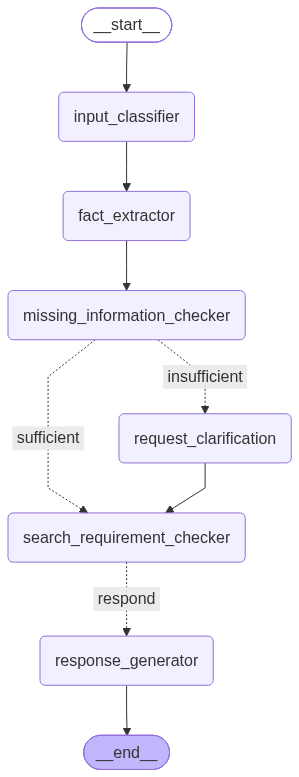

In [15]:
show_graph(basic_graph)

In [16]:
# 질문 경로: 검색/계산 없이 바로 답변
stage1_question = basic_graph.invoke(
    new_state("리모트워크의 장점이 뭐야?"),
    config={"configurable": {"thread_id": "stage1-question"}},
)
print("[1단계-질문] completed:", stage1_question["completed"])
print("[1단계-질문] 답변 앞부분:", stage1_question["final_answer"][:40], "...")

[1단계-질문] completed: True
[1단계-질문] 답변 앞부분: 리모트워크의 장점은 여러 가지가 있습니다:

1. **유연한 근무 시간* ...


In [17]:

# HITL 경로: 정보 부족 -> interrupt -> 같은 thread_id로 재개
stage1_config = {"configurable": {"thread_id": "stage1-hitl"}}
stage1_paused = basic_graph.invoke(new_state("이 문서를 검토해줘"), config=stage1_config)
print("[1단계-HITL] 중단 여부:", "__interrupt__" in stage1_paused)

[1단계-HITL] 중단 여부: True


In [18]:
stage1_resumed = basic_graph.invoke(Command(resume="온보딩"), config=stage1_config)
print("[1단계-HITL] 재개 후 clarification:", stage1_resumed["clarification"])
print("[1단계-HITL] 검색 없이 나오는 안전한 fallback 응답:", stage1_resumed["final_answer"])

[1단계-HITL] 재개 후 clarification: 온보딩
[1단계-HITL] 검색 없이 나오는 안전한 fallback 응답: 확인된 근거가 부족하여 확정적으로 답변할 수 없습니다. 관련 문서를 다시 확인해 주세요.


In [19]:
assert stage1_question["completed"] is True
assert "__interrupt__" in stage1_paused
assert stage1_resumed["clarification"] == "온보딩"
assert stage1_resumed["final_answer"] == SEARCH_FAILURE_MESSAGE
print("1단계 체크포인트 통과 - 7.11에서 Tool Agent 루프를 연결한다.")

1단계 체크포인트 통과 - 7.11에서 Tool Agent 루프를 연결한다.


### 7.11 2단계: Tool Agent 루프 연결 (10-Node 완성)

7.10에서 확인한 1단계 Graph에 `generate_search_query`, `tool_agent`, `tools`,
`evidence_validator`를 추가로 연결해 최종 10-Node Graph를 완성한다.
`request_clarification`은 종료점이 아니라 Checkpoint에 중단 상태를 저장한 뒤,
사용자 응답을 받으면 `search_requirement_checker`로 이어지는 Node라는 점은
1단계와 동일하다.

In [20]:
def build_knowledge_agent_graph(checkpointer=None):
    """Adaptive Workflow와 Tool Agent를 10개 Node로 통합한다."""
    builder = StateGraph(KnowledgeAgentState)
    builder.add_node("input_classifier", classify_input)
    builder.add_node("fact_extractor", fact_extractor)
    builder.add_node("missing_information_checker", missing_information_checker)
    builder.add_node("request_clarification", request_clarification)
    builder.add_node("search_requirement_checker", search_requirement_checker)
    builder.add_node("generate_search_query", generate_search_query)
    builder.add_node("tool_agent", tool_agent_node)
    builder.add_node("tools", ToolNode(KNOWLEDGE_TOOLS))
    builder.add_node("evidence_validator", evidence_validator)
    builder.add_node("response_generator", response_generator)

    builder.add_edge(START, "input_classifier")
    builder.add_edge("input_classifier", "fact_extractor")
    builder.add_edge("fact_extractor", "missing_information_checker")
    builder.add_conditional_edges(
        "missing_information_checker",
        route_after_missing_check,
        {"insufficient": "request_clarification", "sufficient": "search_requirement_checker"},
    )
    builder.add_edge("request_clarification", "search_requirement_checker")
    builder.add_conditional_edges(
        "search_requirement_checker",
        route_after_search_requirement,
        {"required": "generate_search_query", "tool": "tool_agent", "respond": "response_generator"},
    )
    builder.add_edge("generate_search_query", "tool_agent")
    # Agent가 Tool Call을 만들면 tools로, 자연어 답을 만들면 응답 Node로 이동한다.
    builder.add_conditional_edges(
        "tool_agent",
        route_after_tool_agent,
        {"tools": "tools", "respond": "response_generator"},
    )
    builder.add_conditional_edges(
        "tools",
        route_after_tools,
        {"validate": "evidence_validator", "agent": "tool_agent"},
    )
    builder.add_conditional_edges(
        "evidence_validator",
        route_after_evidence,
        {"retry": "generate_search_query", "generate": "response_generator"},
    )
    builder.add_edge("response_generator", END)
    # Checkpointer가 있어야 interrupt 후 같은 thread_id로 Graph를 재개할 수 있다.
    return builder.compile(checkpointer=checkpointer)


knowledge_agent_graph = build_knowledge_agent_graph(InMemorySaver())
print(knowledge_agent_graph)


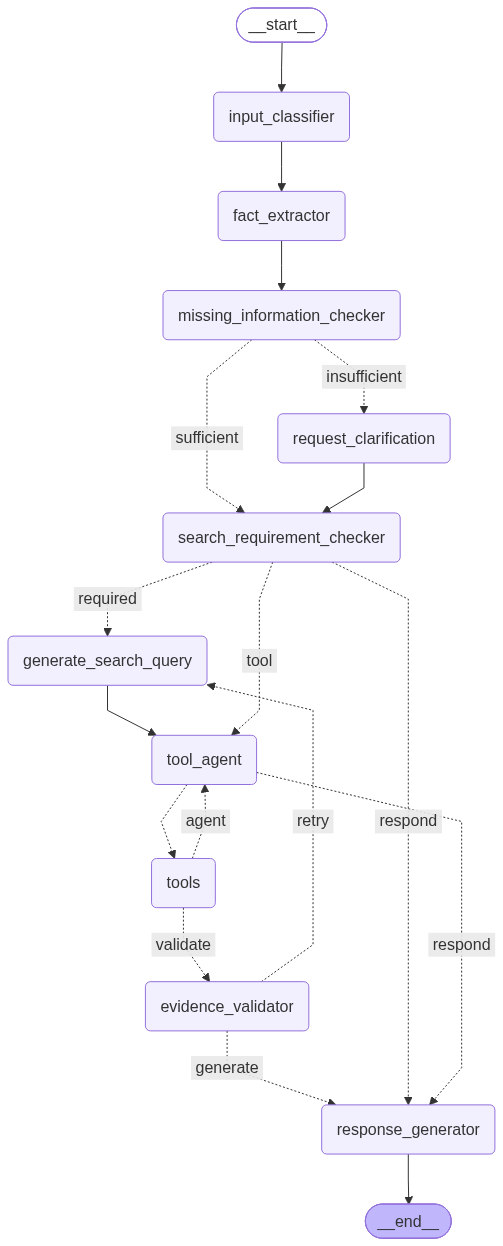

In [21]:
show_graph(knowledge_agent_graph)


### 7.12 실행과 HITL 재개 Helper

모든 실행은 고유한 `thread_id`를 사용한다. 정보 부족 요청에 `clarification`을
함께 전달하면 첫 실행의 Interrupt를 확인한 뒤 같은 Thread에서 재개한다.


In [22]:
def run_knowledge_agent(
    user_input: str,
    thread_id: str,
    clarification: str | None = None,
    graph=knowledge_agent_graph,
) -> dict:
    # 최초 실행과 재개에 동일한 thread_id를 사용해 저장된 Checkpoint를 찾는다.
    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke(new_state(user_input), config=config)
    if "__interrupt__" in result and clarification is not None:
        # Command의 resume 값이 request_clarification 내부 interrupt의 반환값이 된다.
        result = graph.invoke(Command(resume=clarification), config=config)
    return result


sample_result = run_knowledge_agent("128 나누기 4는 얼마야?", "sample-calculation")
print(sample_result["input_type"], "|", sample_result["final_answer"])
print("선택된 Tool:", sample_result["selected_tools"])


calculation | 128 나누기 4는 32입니다.
선택된 Tool: ['calculate_knowledge_tool']


## 8. 실행 결과 관찰

8가지 처리 유형을 실행한다. "정보 부족" 케이스는 첫 실행에서 중단된 뒤
`"온보딩"`을 사용자 답변으로 전달해 같은 Thread에서 실제로 재개한다.


In [23]:
TEST_CASES = [
    ("일반 질문", "리모트워크의 장점이 뭐야?", None),
    ("문서 분석", "문서에서 '온보딩' 관련 내용을 분석해줘", None),
    ("계산 Tool 사용", "128 나누기 4는 얼마야?", None),
    ("지식 검색", "문서에서 '화상회의' 관련 자료를 찾아줘", None),
    ("정보 부족/HITL", "이 문서를 검토해줘", "온보딩"),
    ("검색 실패", "문서에서 '화성 이주' 관련 내용을 찾아줘", None),
    ("지원하지 않는 입력", "노래 한 곡 불러줘", None),
    ("Tool 실행 실패", "10 나누기 0은?", None),
]

observation_results = []
for index, (label, user_input, clarification) in enumerate(TEST_CASES, start=1):
    outcome = run_knowledge_agent(
        user_input,
        thread_id=f"observation-{index}",
        clarification=clarification,
    )
    observation_results.append({
        "label": label,
        "input": user_input,
        "hitl_resumed": clarification is not None,
        **outcome,
    })
    print(
        f"[{label:16}] type={outcome['input_type']:11} | "
        f"tools={outcome['selected_tools']} | completed={outcome['completed']} | "
        f"답변: {outcome['final_answer']}"
    )


[일반 질문           ] type=question    | tools=[] | completed=True | 답변: 리모트워크(원격근무)의 장점은 여러 가지가 있습니다:

1. **유연한 근무 시간**: 출퇴근 시간에 구애받지 않고 개인 일정에 맞춰 일할 수 있어 워라밸(일과 삶의 균형)이 향상됩니다.

2. **출퇴근 시간 및 비용 절감**: 통근 시간이 없어지고 교통비, 주차비 등 비용이 절감됩니다.

3. **생산성 향상**: 조용하고 집중할 수 있는 환경에서 일할 수 있어 업무 효율이 높아질 수 있습니다.

4. **지리적 제약 해소**: 장소에 구애받지 않고 전 세계 어디서든 근무할 수 있어 인재 채용 범위가 넓어집니다.

5. **스트레스 감소**: 출퇴근 스트레스가 줄고, 개인 공간에서 편안하게 일할 수 있어 정신적 부담이 감소합니다.

6. **환경 보호**: 교통량 감소로 탄소 배출이 줄어들어 환경에도 긍정적인 영향을 미칩니다.

이처럼 리모트워크는 개인과 기업 모두에게 다양한 이점을 제공합니다.
[문서 분석           ] type=document    | tools=['search_knowledge_tool'] | completed=True | 답변: 문서에 따르면 '온보딩'과 관련된 내용은 [d4]에 명시되어 있습니다. 일부 부서에서 리모트워크(재택근무)와 사무실 근무 인원 간에 정보 격차가 발생하였고, 특히 신입 직원의 온보딩 과정에서 어려움이 보고된 점이 확인됩니다. 이는 신입 직원이 원활하게 조직에 적응하고 업무를 익히는 데 있어 리모트워크 환경이 장애 요인으로 작용했음을 시사합니다.

한편, [d8]에서는 재택근무 직원이 매일 오전 정기 화상 회의에 참여해 업무 현황을 공유해야 한다고 되어 있으나, 온보딩과 직접적으로 연결된 내용은 포함되어 있지 않습니다.

요약하면, 문서 내 온보딩 관련 내용은 신입 직원이 리모트워크 환경에서 정보 격차로 인해 온보딩에 어려움을 겪고 있다는 점에 집중되어 있습니다.
[계산 Tool 

**결과 해석**

- 계산과 문서 검색에서 각각 `calculate_knowledge_tool`, `search_knowledge_tool`이 선택된다.
- 정보 부족 요청은 Interrupt 후 같은 Thread에서 재개되어 검색과 답변까지 완료된다.
- 검색 실패는 `retry_count`가 `max_retries`에 도달하면 근거 부족 응답으로 끝난다.
- Tool 실패는 검색 실패와 달리 `error`가 설정되어 즉시 오류 응답으로 끝난다.


## 9. 실패 실험: Tool 실패보다 결과 필드를 먼저 읽으면?

Tool이 실패하면 `tool_results`에는 실패 정보가 있고 `error`가 설정되지만 성공
결과인 `value`는 없다. 최종 응답 Node가 `error`를 먼저 확인해야 하는 이유를 확인한다.


In [24]:
def broken_response_generator(state: KnowledgeAgentState) -> dict:
    """error 확인 없이 성공 Tool 결과를 가정한 잘못된 예시."""
    if state["input_type"] == "calculation":
        value = state["tool_results"][-1]["value"]
        return {"final_answer": f"계산 결과: {value}", "completed": True}
    return {"final_answer": "직접 답변", "completed": True}


broken_state = {
    **new_state("10 나누기 0은?"),
    "input_type": "calculation",
    "error": "0으로 나눌 수 없습니다.",
    "tool_results": [{
        "tool": "calculate_knowledge_tool",
        "success": False,
        "error": "0으로 나눌 수 없습니다.",
    }],
}

try:
    broken_response_generator(broken_state)
    print("오류 없이 실행됨 (예상과 다름)")
except Exception as exc:
    print("실패:", type(exc).__name__, exc)


실패: KeyError 'value'


**원인 분석 질문**

- 실패한 Tool 결과에는 `value`가 있는가?
- `broken_response_generator`는 `state["error"]`를 먼저 확인하는가?
- 검색 실패와 Tool 실패의 State 필드를 구분하지 않으면 어떤 잘못된 접근이 생기는가?


## 10. 오류 수정 실습

올바른 `response_generator`는 가장 먼저 `error`를 확인한다. 이 순서만으로도
실패한 Tool 결과의 존재하지 않는 필드에 접근하지 않고 안전한 오류 응답을 만든다.


In [25]:
fixed_result = response_generator({**new_state("10 나누기 0은?"), "input_type": "calculation",
                                    "error": "0으로 나눌 수 없습니다.", "extracted_facts": {"expression": "10/0"}})
print(fixed_result)
assert fixed_result["final_answer"].startswith("[오류]")
assert fixed_result["completed"] is True
print("재검증 통과")

{'final_answer': '[오류] 0으로 나눌 수 없습니다.', 'citations': [], 'completed': True}
재검증 통과


## 11. 도전 과제

1. `InMemorySaver`를 SQLite/Postgres 기반 Checkpointer로 바꿔 프로세스 재시작 후에도 Thread를 재개한다.
2. Tool 호출 전에 사용자 권한을 확인하는 승인용 `interrupt()`를 추가한다.
3. Chroma Metadata Filter를 Tool 인자로 추가해 문서·Section 범위를 제한한다.


## 12. 테스트

**테스트 유형: End-to-End 외부 API 통합 테스트 — LLM + Embedding + Chroma + HITL**

전체 Agent 경로를 실제 모델로 검증한다. Tool 선택과 근거 평가는 모델 판단에 따라 달라질 수 있으므로 실패하면 코드뿐 아니라 API Key, 네트워크, 모델 응답과 Chroma Collection 상태를 함께 확인한다.

In [26]:
graph_instance = build_knowledge_agent_graph(InMemorySaver())
assert graph_instance is not None

question_result = run_knowledge_agent("리모트워크의 장점이 뭐야?", "test-question", graph=graph_instance)
assert question_result["input_type"] == "question"
assert question_result["completed"] is True

calc_result = run_knowledge_agent("128 나누기 4는 얼마야?", "test-calc", graph=graph_instance)
assert calc_result["input_type"] == "calculation"
assert "calculate_knowledge_tool" in calc_result["selected_tools"]
assert "32" in calc_result["final_answer"]

doc_result = run_knowledge_agent(
    "문서에서 '온보딩' 관련 내용을 분석해줘", "test-document", graph=graph_instance
)
assert doc_result["input_type"] == "document"
assert "search_knowledge_tool" in doc_result["selected_tools"]
assert doc_result["evidence_valid"] is True
assert len(doc_result["citations"]) > 0

hitl_config = {"configurable": {"thread_id": "test-hitl"}}
paused_result = graph_instance.invoke(new_state("이 문서를 검토해줘"), config=hitl_config)
assert "__interrupt__" in paused_result
resumed_result = graph_instance.invoke(Command(resume="온보딩"), config=hitl_config)
assert resumed_result["clarification"] == "온보딩"
assert resumed_result["completed"] is True
assert "search_knowledge_tool" in resumed_result["selected_tools"]

search_fail_result = run_knowledge_agent(
    "문서에서 '화성 이주' 관련 내용을 찾아줘", "test-search-fail", graph=graph_instance
)
assert search_fail_result["evidence_valid"] is False
assert search_fail_result["retry_count"] == MAX_RETRIES
assert search_fail_result["final_answer"] == SEARCH_FAILURE_MESSAGE

unsupported_result = run_knowledge_agent("노래 한 곡 불러줘", "test-unsupported", graph=graph_instance)
assert unsupported_result["input_type"] == "unsupported"
assert unsupported_result["final_answer"] == UNSUPPORTED_MESSAGE

tool_fail_result = run_knowledge_agent("10 나누기 0은?", "test-tool-fail", graph=graph_instance)
assert tool_fail_result["error"] is not None
assert tool_fail_result["final_answer"].startswith("[오류]")

required_fields = {
    "user_input", "input_type", "extracted_facts", "missing_information", "clarification",
    "search_required", "search_queries", "retrieved_documents", "evidence_valid",
    "selected_tools", "tool_results", "retry_count", "max_retries", "completed",
    "error", "citations", "final_answer",
}
assert required_fields.issubset(KnowledgeAgentState.__annotations__)
assert "messages" in MessagesState.__annotations__

print("10-Node Tool Agent + Chroma + HITL 테스트 통과")


10-Node Tool Agent + Chroma + HITL 테스트 통과


## 13. 결과 저장

In [27]:
knowledge_agent_log = {
    "architecture": "Adaptive Workflow + Tool Agent",
    "node_count": 10,
    "vector_store": {"type": "Chroma", "collection": COLLECTION_NAME, "path": str(CHROMA_DIR)},
    "test_cases": [
        {
            "label": result["label"],
            "input": result["input"],
            "input_type": result["input_type"],
            "hitl_resumed": result["hitl_resumed"],
            "selected_tools": result["selected_tools"],
            "completed": result["completed"],
            "retry_count": result["retry_count"],
            "evidence_valid": result["evidence_valid"],
            "error": result["error"],
            "final_answer": result["final_answer"],
        }
        for result in observation_results
    ],
    "llm_call_count": LLM_CALL_COUNT,
}
saved_path = save_log(
    knowledge_agent_log,
    OUTPUT_DIR / "logs" / "05-1_integrated_knowledge_agent_log.json",
)
print("저장 위치:", saved_path)


저장 위치: E:\agentic_ai_lab\outputs\logs\05-1_integrated_knowledge_agent_log.json


## 14. 핵심 정리

- 최종 결과물은 조건 분기만 있는 Workflow가 아니라, 그 안에 `LLM → ToolNode → LLM` Agent Loop를 포함한 Hybrid Agent다.
- 계산과 검색 Tool은 LLM이 선택하고 `ToolNode`가 실행하며, 결과는 `MessagesState`와 업무 State에 함께 기록된다.
- 디스크 기반 `sample_documents` Collection을 열어, 이미 문서가 있으면(예: 03-2 실습 이후) 그대로 재사용한다.
- 정보 부족은 `interrupt()`로 중단되고, Checkpointer와 같은 `thread_id`를 사용한 `Command(resume=...)`로 재개된다.
- 검색 실패, Tool 실패, HITL은 원인과 복구 방식이 다르므로 각각 별도 경로로 설계한다.

## 15. 확인 문제

1. 이 Graph를 순수 Tool Agent가 아니라 Hybrid Agent라고 부르는 이유는 무엇인가?
2. 계산 요청과 문서 검색 요청에서 `tool_agent → tools` 이후 경로는 어떻게 달라지는가?
3. `request_clarification`에서 Checkpointer와 `thread_id`가 필요한 이유는 무엇인가?
4. Chroma 검색 결과가 부족할 때 Tool 실패와 달리 재시도할 수 있는 이유는 무엇인가?
5. `tools_condition`은 어떤 메시지를 보고 `tools` 경로를 선택하는가?
